# Pricebook — Quickstart

A 20-minute introduction to the library. By the end you will:

1. Build a discount curve by bootstrap from deposits + swaps.
2. Price a fixed-rate bond (dirty/clean price + DV01).
3. Price an interest-rate swap (PV + par rate).
4. Price a European equity option (Black-Scholes).
5. Round-trip an instrument through `to_dict()` / `from_dict()`.
6. Plot the curve and a Greeks profile with `pricebook.viz`.

Library version: see `RELEASE_NOTES.md`. ~780 modules, 11500+ tests, 33 markets.

In [1]:
import sys, os
# Allow running from notebooks/examples without installing the package.
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "python"))

from datetime import date, timedelta
from pricebook.viz import configure_theme

configure_theme(seaborn_style="whitegrid", seaborn_context="notebook")
print("Pricebook quickstart loaded.")

Pricebook quickstart loaded.


## 1. Build a discount curve

Bootstrap from a short money-market segment (deposits) plus a longer swap segment.
The returned `DiscountCurve` reprices every input by construction.

In [2]:
from pricebook.curves.bootstrap import bootstrap

REF = date(2026, 6, 1)

deposits = [
    (REF + timedelta(days=30),  0.0530),
    (REF + timedelta(days=91),  0.0525),
    (REF + timedelta(days=182), 0.0510),
]
swaps = [
    (REF + timedelta(days=365),   0.0480),
    (REF + timedelta(days=365*2), 0.0445),
    (REF + timedelta(days=365*5), 0.0410),
    (REF + timedelta(days=365*10),0.0395),
    (REF + timedelta(days=365*30),0.0385),
]

curve = bootstrap(REF, deposits, swaps)
print(f"df(1Y)  = {curve.df(REF + timedelta(days=365)):.6f}")
print(f"df(5Y)  = {curve.df(REF + timedelta(days=365*5)):.6f}")
print(f"df(10Y) = {curve.df(REF + timedelta(days=365*10)):.6f}")

df(1Y)  = 0.953717
df(5Y)  = 0.817169
df(10Y) = 0.678073


## 2. Price a fixed-rate bond

A 5% coupon, 10-year bond with semi-annual payments. We get dirty price, clean
price, accrued interest, and the modified-duration DV01.

In [3]:
from pricebook.fixed_income.bond import FixedRateBond
from pricebook.core.schedule import Frequency

bond = FixedRateBond(
    issue_date=REF,
    maturity=REF + timedelta(days=365*10),
    coupon_rate=0.05,
    frequency=Frequency.SEMI_ANNUAL,
)

dirty = bond.dirty_price(curve)
settlement = REF + timedelta(days=2)
clean = bond.clean_price(curve, settlement)
accrued = bond.accrued_interest(settlement)

print(f"dirty price = {dirty:.4f}")
print(f"clean price = {clean:.4f}")
print(f"accrued     = {accrued:.4f}")

ytm = bond.yield_to_maturity(market_price=dirty, settlement=settlement)
mod_dur = bond.modified_duration(ytm, settlement=settlement)
print(f"YTM         = {ytm*100:.3f}%")
print(f"mod dur     = {mod_dur:.4f}")

dirty price = 108.5575
clean price = 108.5298
accrued     = 0.0278
YTM         = 3.958%
mod dur     = 7.9188


## 3. Price an interest-rate swap

A 5-year vanilla payer swap (pay 4.10% fixed, receive 3M floating) on $10mm.
The bootstrapped curve discounts both legs and projects the floating leg.

In [4]:
from pricebook.fixed_income.swap import InterestRateSwap, SwapDirection

swap = InterestRateSwap(
    start=REF,
    end=REF + timedelta(days=365*5),
    fixed_rate=0.0410,
    direction=SwapDirection.PAYER,
    notional=10_000_000,
)

pv = swap.pv(curve)
par = swap.par_rate(curve)
dv01 = swap.dv01(curve)
print(f"swap PV  = {pv:,.2f}")
print(f"par rate = {par*100:.4f}%")
print(f"DV01     = {dv01:,.2f}")

swap PV  = -0.00
par rate = 4.1000%
DV01     = 4,573.06


## 4. Price a European equity option

Black-Scholes call: spot=100, K=105, vol=25%, 1y, r=4%, q=2%.

In [5]:
import dataclasses
from pricebook.options.equity_option import equity_option_price, equity_greeks
from pricebook.models.black76 import OptionType

px = equity_option_price(
    spot=100.0, strike=105.0, rate=0.04, vol=0.25, T=1.0,
    div_yield=0.02, option_type=OptionType.CALL,
)
greeks = equity_greeks(
    spot=100.0, strike=105.0, rate=0.04, vol=0.25, T=1.0,
    div_yield=0.02, option_type=OptionType.CALL,
)
print(f"price = {px:.4f}")
for field in dataclasses.fields(greeks):
    print(f"  {field.name:7s} = {getattr(greeks, field.name): .6f}")

price = 8.5267
  price   =  8.526740
  delta   =  0.493947
  gamma   =  0.015641
  vega    =  39.102377
  theta   = -5.534621
  rho     =  40.867947
  vanna   =  0.000000
  volga   =  0.000000


## 5. Serialise an instrument — round-trip via `to_dict()` / `from_dict()`

Every trade in pricebook can be persisted as a JSON-native dict. The global
registry dispatches `from_dict()` on the `type` key, so a portfolio can be
saved to disk and reloaded without losing instrument type.

In [6]:
import json
from pricebook.fixed_income.money_market import CertificateOfDeposit
from pricebook.core.serialisable import from_dict

cd = CertificateOfDeposit(
    settlement=REF,
    maturity=REF + timedelta(days=180),
    face_value=1_000_000,
    coupon_rate=0.048,
)

# Round-trip
d = cd.to_dict()
print("Serialised:")
print(json.dumps(d, indent=2, default=str))

rebuilt = from_dict(d)  # registry dispatch on d["type"]
print()
print(f"Original type:  {type(cd).__name__}")
print(f"Rebuilt type:   {type(rebuilt).__name__}")
print(f"Original cash:  {cd.maturity_cashflow:,.2f}")
print(f"Rebuilt cash:   {rebuilt.maturity_cashflow:,.2f}")

Serialised:
{
  "type": "certificate_of_deposit",
  "params": {
    "settlement": "2026-06-01",
    "maturity": "2026-11-28",
    "face_value": 1000000,
    "coupon_rate": 0.048,
    "day_count": "ACT/360"
  }
}

Original type:  CertificateOfDeposit
Rebuilt type:   CertificateOfDeposit
Original cash:  1,024,000.00
Rebuilt cash:   1,024,000.00


## 6. Visualise — curve and a Greeks profile

`pricebook.viz` is the only sanctioned plotting layer. It wraps matplotlib +
seaborn with a consistent theme. Never import `matplotlib.pyplot` directly.

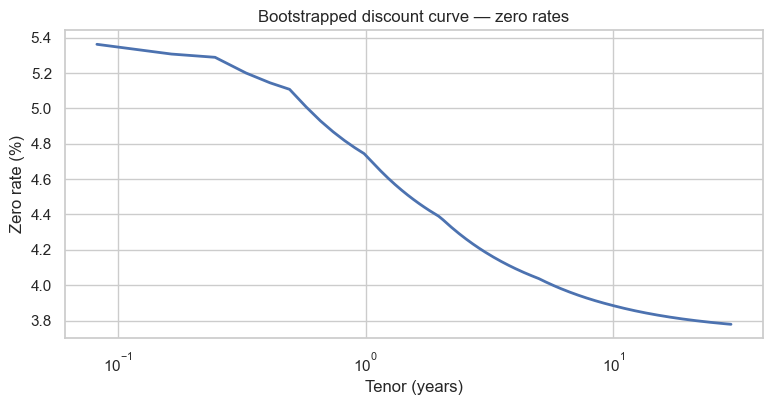

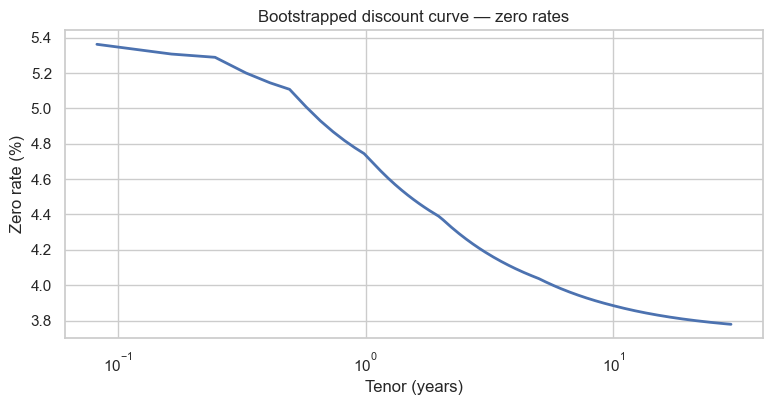

In [7]:
import numpy as np
from pricebook.viz._backend import create_figure

# Discount-factor curve → zero rates
fig, axes = create_figure(n_panels=1, figsize=(9, 4))
ax = axes[0]

days = np.arange(30, 365*30, 30)
dates = [REF + timedelta(days=int(d)) for d in days]
dfs = [curve.df(d) for d in dates]
zeros = [-np.log(df) / (d/365) for df, d in zip(dfs, days)]

ax.plot(days/365, [z*100 for z in zeros], lw=2)
ax.set_xlabel("Tenor (years)")
ax.set_ylabel("Zero rate (%)")
ax.set_title("Bootstrapped discount curve — zero rates")
ax.set_xscale("log")
fig

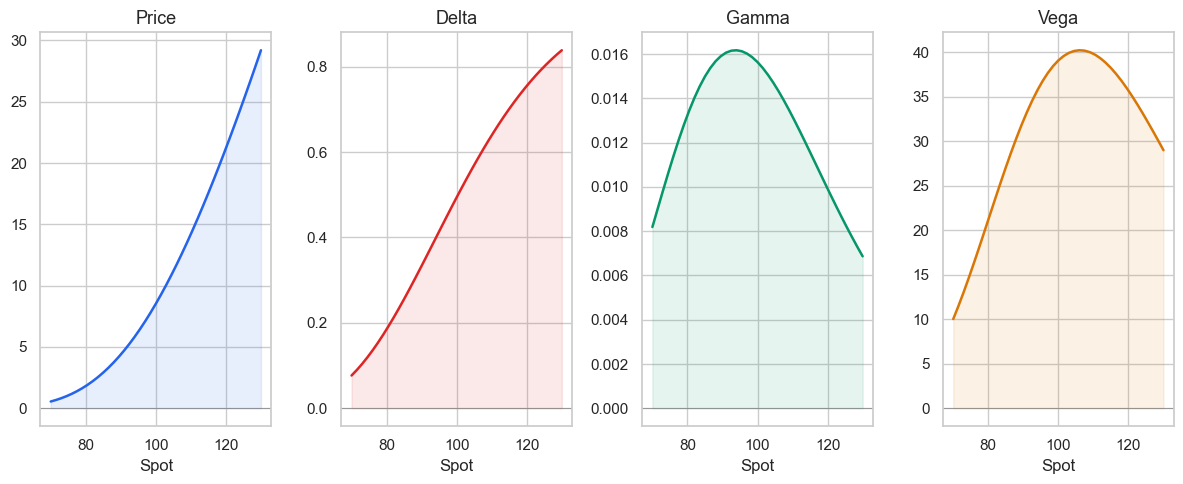

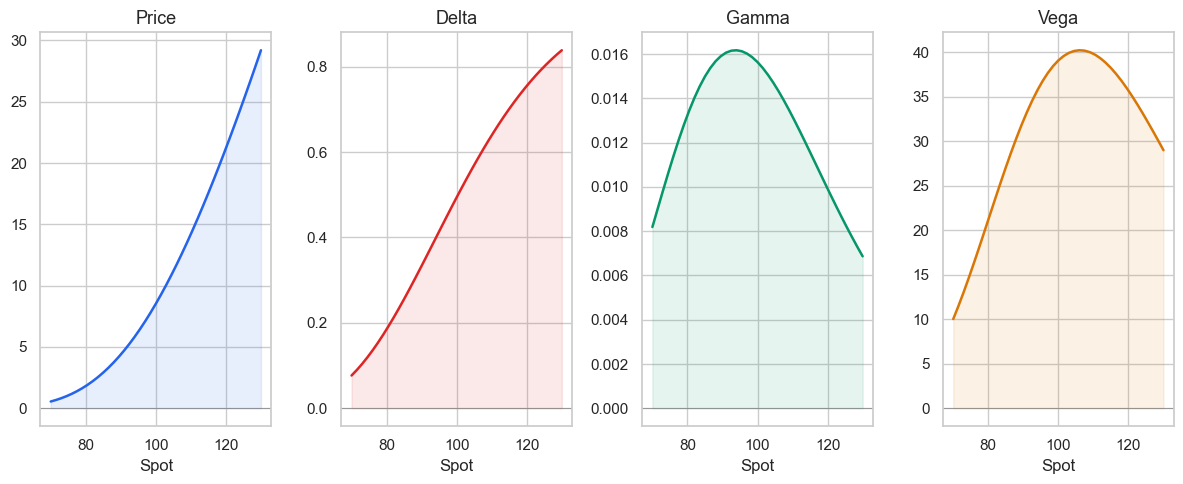

In [8]:
from pricebook.viz import greeks_profile

# Spot ladder for the equity option
spots = np.linspace(70, 130, 41)
prices, deltas, gammas, vegas = [], [], [], []
for s in spots:
    g = equity_greeks(spot=float(s), strike=105.0, rate=0.04, vol=0.25, T=1.0,
                      div_yield=0.02, option_type=OptionType.CALL)
    prices.append(g.price); deltas.append(g.delta); gammas.append(g.gamma); vegas.append(g.vega)

fig = greeks_profile(
    spot_range=spots,
    greeks_by_spot={"Price": prices, "Delta": deltas, "Gamma": gammas, "Vega": vegas},
    title="Equity call — Greeks vs spot (K=105, vol=25%, T=1y)",
)
fig

## Where next

- **Notebooks**: `notebooks/desks/` for trader workflows, `notebooks/papers/` for paper validations, `notebooks/structured/` for PRDC/TARF/xccy.
- **API entry points** by layer:
  - Curves: `pricebook.curves.bootstrap`, `pricebook.curves.global_solver`
  - Instruments: `pricebook.fixed_income.*`, `pricebook.fx.*`, `pricebook.equity.*`, `pricebook.credit.*`, `pricebook.commodity.*`, `pricebook.options.*`, `pricebook.crypto.*`
  - Models: `pricebook.models.*` (Hull-White, G2++, Heston, SABR, LMM, COS, FFT, AAD, Fokker-Planck, ...)
  - Numerics: `pricebook.numerical.*` (PDE, Fourier, MC, optimisation, AD)
  - Desks: `pricebook.desks.*` (bond, futures, swap, crypto, ...)
  - Viz: `pricebook.viz` (always — never raw `matplotlib`)
- **Architecture**: `ARCHITECTURE.md` at the repo root.